PTB timestamps  (85 entries):
[         0   62500000  125000000  187500000  250000000  312500000
  375000000  437500000  500000000  562500000  625000000  687500000
  750000000  812500000  875000000  937500000 1000000000 1062500000
 1125000000 1187500000 1250000000 1312500000 1375000000 1437500000
 1500000000 1562500000 1625000000 1687500000 1750000000 1812500000
 1875000000 1937500000 2000000000 2062500000 2125000000 2187500000
 2250000000 2312500000 2375000000 2437500000 2500000000 2562500000
 2625000000 2687500000 2750000000 2812500000 2875000000 2937500000
 3000000000 3062500000 3125000000 3187500000 3250000000 3312500000
 3375000000 3437500000 3500000000 3562500000 3625000000 3687500000
 3750000000 3812500000 3875000000 3937500000 4000000000 4062500000
 4125000000 4187500000 4250000000 4312500000 4375000000 4437500000
 4500000000 4562500000 4625000000 4687500000 4750000000 4812500000
 4875000000 4937500000 5000000000 5062500000 5125000000 5187500000
 5250000000]

Muon timestamps (8

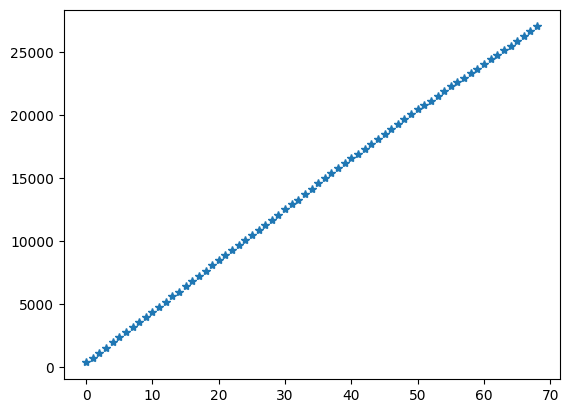

In [11]:
import re
import numpy as np
import matplotlib.pyplot as plt
 
filepath = "muon_times.txt"
 
ptb_pattern  = re.compile(r'\[ptb\]\s+timestamp:\s+(0x[0-9a-fA-F]+)', re.IGNORECASE)
muon_pattern = re.compile(r'\[muon\]\s+timestamp:\s+(0x[0-9a-fA-F]+)', re.IGNORECASE)
 
ptb_times  = []
muon_times = []
 
with open(filepath, 'r') as f:
    for line in f:
        ptb_match = ptb_pattern.search(line)
        if ptb_match:
            ptb_times.append(int(ptb_match.group(1), 16))
 
        muon_match = muon_pattern.search(line)
        if muon_match:
            muon_times.append(int(muon_match.group(1), 16))
 
ptb_array  = np.array(ptb_times,  dtype=np.uint64)
muon_array = np.array(muon_times, dtype=np.uint64)*0.625
 
print(f"PTB timestamps  ({len(ptb_array)} entries):")
print(ptb_array)
 
print(f"\nMuon timestamps ({len(muon_array)} entries):")
print(muon_array)

plt.plot(ptb_array[1:70]-muon_array[1:70],"*")


In [1]:
import re
import matplotlib.pyplot as plt

LOG_FILE = "muon_test.txt"  # <-- update path if needed

# Capture the timestamp field from each line type
MUON_RE = re.compile(r'^\[muon\].*?timestamp:\s*(0x[0-9a-fA-F]+)')
PTB_RE  = re.compile(r'^\[ptb\].*?timestamp:\s*(0x[0-9a-fA-F]+)')

In [12]:
muon_timestamps = []
ptb_timestamps  = []

with open(LOG_FILE, 'r') as f:
    for line in f:
        m = MUON_RE.match(line)
        if m:
            muon_timestamps.append(int(m.group(1), 16))
            continue
        p = PTB_RE.match(line)
        if p:
            ptb_timestamps.append(int(p.group(1), 16))

print(f"Muon events : {len(muon_timestamps):,}")
print(f"PTB  events : {len(ptb_timestamps):,}")
muon_timestamps = np.array(muon_timestamps[1:])
muon_timestamps = muon_timestamps-45869399519 

Muon events : 11,485
PTB  events : 11,484


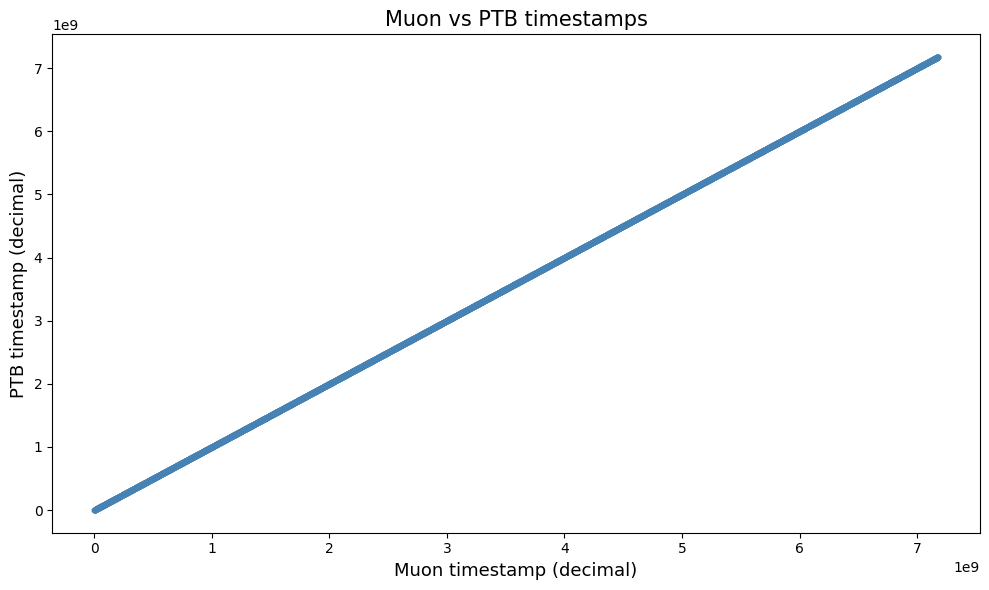

In [13]:
n = min(len(muon_timestamps), len(ptb_timestamps))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(muon_timestamps[:n], ptb_timestamps[:n],
           s=10, alpha=0.6, color='steelblue')

ax.set_xlabel('Muon timestamp (decimal)', fontsize=13)
ax.set_ylabel('PTB timestamp (decimal)',  fontsize=13)
ax.set_title('Muon vs PTB timestamps', fontsize=15)
ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))

plt.tight_layout()
plt.savefig('muon_vs_ptb_scatter.png', dpi=150)
plt.show()

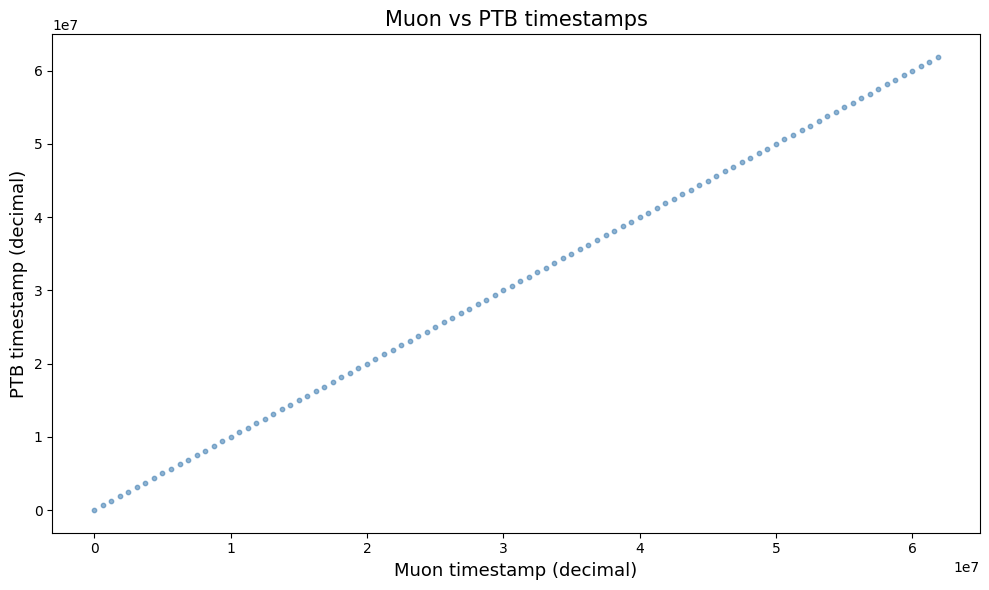

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(muon_timestamps[0:100], ptb_timestamps[0:100],
           s=10, alpha=0.6, color='steelblue')

ax.set_xlabel('Muon timestamp (decimal)', fontsize=13)
ax.set_ylabel('PTB timestamp (decimal)',  fontsize=13)
ax.set_title('Muon vs PTB timestamps', fontsize=15)
ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))

plt.tight_layout()
plt.savefig('muon_vs_ptb_scatter.png', dpi=150)
plt.show()

In [17]:
for i in range(0,100):
    print(muon_timestamps[i],ptb_timestamps[i])

0 0
625000 625000
1250000 1250000
1874998 1875000
2499998 2500000
3124998 3125000
3750000 3750000
4375000 4375000
5000000 5000000
5624998 5625000
6249998 6250000
6874998 6875000
7499998 7500000
8124998 8125000
8750000 8750000
9375000 9375000
10000000 10000000
10625000 10625000
11249998 11250000
11874998 11875000
12500000 12500000
13124998 13125000
13749998 13750000
14375000 14375000
14999998 15000000
15624998 15625000
16249998 16250000
16874998 16875000
17499998 17500000
18125000 18125000
18749998 18750000
19374998 19375000
20000000 20000000
20624998 20625000
21249998 21250000
21875000 21875000
22499998 22500000
23124998 23125000
23749998 23750000
24375000 24375000
25000000 25000000
25625000 25625000
26250000 26250000
26875000 26875000
27499998 27500000
28124998 28125000
28750000 28750000
29375000 29375000
29999998 30000000
30624998 30625000
31249998 31250000
31875000 31875000
32499998 32500000
33125000 33125000
33749998 33750000
34375000 34375000
35000000 35000000
35624998 35625000
36

In [18]:
for i in range(0,100):
    print(muon_timestamps[-i],ptb_timestamps[-i])

0 0
7176874998 7176875000
7176249998 7176250000
7175625000 7175625000
7174999998 7175000000
7174374998 7174375000
7173749998 7173750000
7173124998 7173125000
7172499998 7172500000
7171875000 7171875000
7171249998 7171250000
7170625000 7170625000
7169999998 7170000000
7169375000 7169375000
7168749998 7168750000
7168125000 7168125000
7167499998 7167500000
7166874998 7166875000
7166250000 7166250000
7165624998 7165625000
7165000000 7165000000
7164374998 7164375000
7163750000 7163750000
7163124998 7163125000
7162499998 7162500000
7161874998 7161875000
7161250000 7161250000
7160625000 7160625000
7160000000 7160000000
7159374998 7159375000
7158750000 7158750000
7158125000 7158125000
7157499998 7157500000
7156874998 7156875000
7156250000 7156250000
7155625000 7155625000
7155000000 7155000000
7154375000 7154375000
7153750000 7153750000
7153125000 7153125000
7152499998 7152500000
7151874998 7151875000
7151250000 7151250000
7150624998 7150625000
7149999998 7150000000
7149375000 7149375000
714874

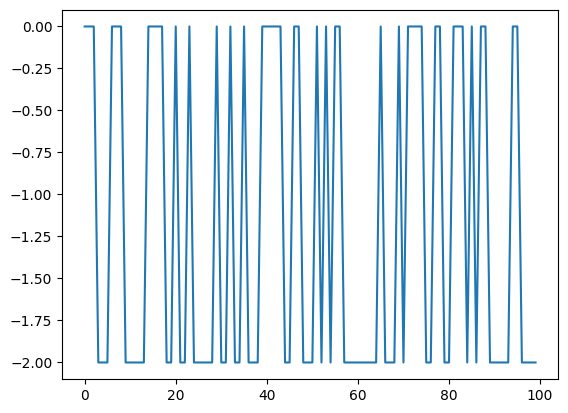

In [24]:
plt.plot(muon_timestamps[0:100]-ptb_timestamps[0:100])
plt.show()

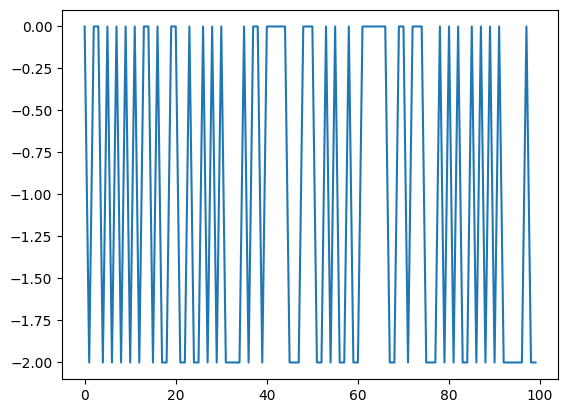

In [25]:
plt.plot(muon_timestamps[-100:]-ptb_timestamps[-100:])
plt.show()